In [252]:
import pandas as pd
import numpy as np
import subprocess
import os
from datetime import datetime, timedelta, time, date
import datetime
from datetime import datetime
import locale
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [253]:
dia = "20260519"

dia_i = '19/05/2026'
dia_f = '19/05/2026'

Viaje desglosado

In [254]:
#Viaje desglosado

desglosado_z = pd.read_csv(f'Z:/01 base_datos/01 viajes_desglosados_FMS/{dia}_viajedesglosado.csv',encoding='latin')
desglosado_t = pd.read_csv(f'Z:/01 base_datos/16 viajes_desglosados_alimentacion_FMS/{dia}_viajedesglosadotroncal.csv',encoding='latin')

desglosado = pd.concat([desglosado_z,desglosado_t], ignore_index=True)

desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,DistNoRealizada,KmEjecutado,DespInicial,Puntualidad Preliminar,IdValPuntualidad,Cumplimiento Preliminar,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar
0,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-1-12739,BC29D0002,1,2,1,10350,...,0,36341,Si,NaN,NaN,NaN,"1, 1",CDZ4,100.0,1.0
1,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-2-12738,BC29D0002,2,3,2,10350,...,0,36909,No,NaN,NaN,NaN,"1, 3",CDZ4,100.0,1.0
2,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-3-12739,BC29D0002,3,4,3,10350,...,0,36341,No,NaN,NaN,NaN,"1, 4",CDZ4,100.0,1.0
3,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-4-12738,BC29D0002,4,5,4,10350,...,0,36909,No,NaN,NaN,NaN,"1, 5",CDZ4,100.0,1.0
4,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-5-12739,BC29D0002,5,6,5,10350,...,0,36341,No,NaN,NaN,NaN,"1, 5",CDZ4,100.0,1.0


In [255]:
# Función para corregir tiempos con "24:00:00"
def fix_time(date_str):
    if '24:' in date_str:
        return date_str.replace('24:', '00:')
    elif '25:' in date_str:
        return date_str.replace('25:', '01:')
    elif '26:' in date_str:
        return date_str.replace('26:', '02:')
    elif '27:' in date_str:
        return date_str.replace('27:', '03:')
    elif '28:' in date_str:
        return date_str.replace('28:', '04:')
    elif '29:' in date_str:
        return date_str.replace('29:', '05:')
    else:
        return date_str

# Función para convertir tiempo a segundos
def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

# Convertir la columna de tiempo a cadenas
desglosado['Hora Ini Teorica '] = desglosado['Hora Ini Teorica '].astype(str)

# Aplicar la función para corregir los tiempos
desglosado['Hora Ini Teorica '] = desglosado['Hora Ini Teorica '].apply(fix_time)

# Convertir la columna de tiempo a datetime, usando errors='coerce' para manejar errores
desglosado['Hora Ini Teorica '] = pd.to_datetime(desglosado['Hora Ini Teorica '], format='%H:%M:%S', errors='coerce')

# Eliminar la fecha predeterminada para trabajar solo con la parte de tiempo
desglosado['Hora Ini Teorica '] = desglosado['Hora Ini Teorica '].dt.time

# Manejar NaT después de la conversión
desglosado['Hora Ini Teorica '] = desglosado['Hora Ini Teorica '].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())

# Convertir la columna 'Instante' a segundos
desglosado['Hora Teórica_segundos'] = desglosado['Hora Ini Teorica '].apply(time_to_seconds).astype(int)

desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,KmEjecutado,DespInicial,Puntualidad Preliminar,IdValPuntualidad,Cumplimiento Preliminar,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos
0,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-1-12739,BC29D0002,1,2,1,10350,...,36341,Si,NaN,NaN,NaN,"1, 1",CDZ4,100.0,1.0,14400
1,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-2-12738,BC29D0002,2,3,2,10350,...,36909,No,NaN,NaN,NaN,"1, 3",CDZ4,100.0,1.0,21375
2,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-3-12739,BC29D0002,3,4,3,10350,...,36341,No,NaN,NaN,NaN,"1, 4",CDZ4,100.0,1.0,31500
3,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-4-12738,BC29D0002,4,5,4,10350,...,36909,No,NaN,NaN,NaN,"1, 5",CDZ4,100.0,1.0,40590
4,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-BC29D0002-5-12739,BC29D0002,5,6,5,10350,...,36341,No,NaN,NaN,NaN,"1, 5",CDZ4,100.0,1.0,50370


In [256]:
# Ordenar el DataFrame por 'Linea', 'Ruta' y 'Hora Teórica'
desglosado = desglosado.sort_values(by=['Id Línea ', 'Ruta ', 'Servicio','Hora Teórica_segundos'], ascending=[True, True, True,True])

desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,KmEjecutado,DespInicial,Puntualidad Preliminar,IdValPuntualidad,Cumplimiento Preliminar,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,60920,Si,NaN,NaN,NaN,"1, 1",CDZ4,99.61,1.00,10800
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,59508,No,NaN,NaN,NaN,"1, 3",CDZ4,97.30,0.97,24585
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,61084,No,NaN,NaN,NaN,"1, 5",CDZ4,99.88,1.00,44235
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,59938,No,NaN,NaN,NaN,"1, 7",CDZ4,98.01,0.98,65460
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,59582,Si,NaN,NaN,NaN,"1, 1",CDZ4,97.42,0.97,11175


In [257]:
# Encontrar el mínimo de 'Hora Teórica_segundos' por cada 'Servicio Bus'
desglosado['Primer Viaje'] = (desglosado.groupby('Servicio')['Hora Teórica_segundos']
                         .transform('min') == desglosado['Hora Teórica_segundos']).astype(int)

desglosado.head()


,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,DespInicial,Puntualidad Preliminar,IdValPuntualidad,Cumplimiento Preliminar,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos,Primer Viaje
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,Si,NaN,NaN,NaN,"1, 1",CDZ4,99.61,1.00,10800,1
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,No,NaN,NaN,NaN,"1, 3",CDZ4,97.30,0.97,24585,0
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,No,NaN,NaN,NaN,"1, 5",CDZ4,99.88,1.00,44235,0
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,No,NaN,NaN,NaN,"1, 7",CDZ4,98.01,0.98,65460,0
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,Si,NaN,NaN,NaN,"1, 1",CDZ4,97.42,0.97,11175,1


Eliminación cuando es primer viaje

In [258]:
# Crear la nueva columna 'Resultado' basada en las condiciones proporcionadas
desglosado['Eliminacion_primer_viaje'] = np.where(
    (desglosado['Primer Viaje'] == 1) &
    (desglosado['Eliminado'] == 'Eliminado') &
    (desglosado['Descripción Motivo Elim'] == 'Congestion vehicular'),
    1,
    0
)

# Mostrar el DataFrame resultante
desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,Puntualidad Preliminar,IdValPuntualidad,Cumplimiento Preliminar,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,NaN,NaN,NaN,"1, 1",CDZ4,99.61,1.00,10800,1,0
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,NaN,NaN,NaN,"1, 3",CDZ4,97.30,0.97,24585,0,0
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,NaN,NaN,NaN,"1, 5",CDZ4,99.88,1.00,44235,0,0
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,NaN,NaN,NaN,"1, 7",CDZ4,98.01,0.98,65460,0,0
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,NaN,NaN,NaN,"1, 1",CDZ4,97.42,0.97,11175,1,0


In [259]:
# Función para corregir tiempos con "24:00:00"
def fix_time(date_str):
    if '24:' in date_str:
        return date_str.replace('24:', '00:')
    elif '25:' in date_str:
        return date_str.replace('25:', '01:')
    elif '26:' in date_str:
        return date_str.replace('26:', '02:')
    elif '27:' in date_str:
        return date_str.replace('27:', '03:')
    elif '28:' in date_str:
        return date_str.replace('28:', '04:')
    elif '29:' in date_str:
        return date_str.replace('29:', '05:')
    else:
        return date_str

# Función para convertir tiempo a segundos
def time_to_seconds(time_obj):
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

# Convertir la columna de tiempo a cadenas
desglosado['DurTeor'] = desglosado['DurTeor'].astype(str)
desglosado['DurRef'] = desglosado['DurRef'].astype(str)
desglosado['DurReal'] = desglosado['DurReal'].astype(str)

# Aplicar la función para corregir los tiempos
desglosado['DurTeor'] = desglosado['DurTeor'].apply(fix_time)
desglosado['DurRef'] = desglosado['DurRef'].apply(fix_time)
desglosado['DurReal'] = desglosado['DurReal'].apply(fix_time)

# Convertir la columna de tiempo a datetime, usando errors='coerce' para manejar errores
desglosado['DurTeor'] = pd.to_datetime(desglosado['DurTeor'], format='%H:%M:%S', errors='coerce')
desglosado['DurRef'] = pd.to_datetime(desglosado['DurRef'], format='%H:%M:%S', errors='coerce')
desglosado['DurReal'] = pd.to_datetime(desglosado['DurReal'], format='%H:%M:%S', errors='coerce')

# Eliminar la fecha predeterminada para trabajar solo con la parte de tiempo
desglosado['DurTeor'] = desglosado['DurTeor'].dt.time
desglosado['DurRef'] = desglosado['DurRef'].dt.time
desglosado['DurReal'] = desglosado['DurReal'].dt.time

# Manejar NaT después de la conversión
desglosado['DurTeor'] = desglosado['DurTeor'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())
desglosado['DurRef'] = desglosado['DurRef'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())
desglosado['DurReal'] = desglosado['DurReal'].apply(lambda x: x if pd.notnull(x) else pd.Timestamp('00:00:00').time())

# Convertir la columna 'Instante' a segundos
desglosado['Duración teórica_segundos'] = desglosado['DurTeor'].apply(time_to_seconds).astype(int)
desglosado['Duración referencia_segundos'] = desglosado['DurRef'].apply(time_to_seconds).astype(int)
desglosado['Duración Real_segundos'] = desglosado['DurReal'].apply(time_to_seconds).astype(int)

desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,FraHorCump,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,"1, 1",CDZ4,99.61,1.00,10800,1,0,13620,11820,10791
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,"1, 3",CDZ4,97.30,0.97,24585,0,0,18000,17640,14507
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,"1, 5",CDZ4,99.88,1.00,44235,0,0,20880,18240,19308
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,"1, 7",CDZ4,98.01,0.98,65460,0,0,16905,16905,15282
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,"1, 1",CDZ4,97.42,0.97,11175,1,0,13620,11820,10458


In [260]:
# Crear una nueva columna llamada 'Diferencia Duración' con la diferencia de las dos columnas
desglosado['Diferencia Duración'] = desglosado['Duración referencia_segundos'] - desglosado['Duración teórica_segundos']

# Mostrar el DataFrame con la nueva columna
desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,IdValCumplimiento,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,CDZ4,99.61,1.00,10800,1,0,13620,11820,10791,-1800
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,CDZ4,97.30,0.97,24585,0,0,18000,17640,14507,-360
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,CDZ4,99.88,1.00,44235,0,0,20880,18240,19308,-2640
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,CDZ4,98.01,0.98,65460,0,0,16905,16905,15282,0
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,CDZ4,97.42,0.97,11175,1,0,13620,11820,10458,-1800


In [261]:
# Crear una nueva columna basada en la condición de que la columna de diferencia real es mayor a la programada
desglosado['Diferencia_realizado'] = (desglosado['Duración Real_segundos'] <= desglosado['Duración teórica_segundos']).astype(int)

# Mostrar el DataFrame con la nueva columna
desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,ICK Full Preliminar,ICK Preliminar,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado
1664,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,99.61,1.00,10800,1,0,13620,11820,10791,-1800,1
1665,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,97.30,0.97,24585,0,0,18000,17640,14507,-360,1
1666,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,99.88,1.00,44235,0,0,20880,18240,19308,-2640,1
1667,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,98.01,0.98,65460,0,0,16905,16905,15282,0,1
1668,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,97.42,0.97,11175,1,0,13620,11820,10458,-1800,1


Duración real menor a la programada

In [262]:
# Restablecer el índice del DataFrame
desglosado.reset_index(drop=True, inplace=True)

# Crear una nueva columna para almacenar el resultado
desglosado['eliminacion_duracion_real_menor'] = 0

# Iterar por el DataFrame para aplicar la lógica
for i in range(1, len(desglosado) - 1):  # Comenzamos desde 1 para no ir al primer elemento (sin fila anterior)
    # Verificar la condición para la fila actual y la anterior
    if desglosado.loc[i, 'Diferencia_realizado'] == 1 and desglosado.loc[i - 1, 'Diferencia_realizado'] == 1:
        # Verificar las condiciones para la siguiente fila dentro de la misma Linea y Ruta
        if (
            desglosado.loc[i + 1, 'Servicio'] == desglosado.loc[i, 'Servicio'] and
            desglosado.loc[i + 1, 'Id Línea '] == desglosado.loc[i, 'Id Línea '] and
            desglosado.loc[i + 1, 'Ruta '] == desglosado.loc[i, 'Ruta '] and
            desglosado.loc[i + 1, 'Eliminado'] == 'Eliminado' and
            desglosado.loc[i + 1, 'Descripción Motivo Elim'] == 'Congestion vehicular'
        ):
            # Marcar como 1 si se cumplen todas las condiciones
            desglosado.loc[i, 'eliminacion_duracion_real_menor'] = 1

# Mostrar el DataFrame con la nueva columna
desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,ICK Preliminar,Hora Teórica_segundos,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado,eliminacion_duracion_real_menor
0,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,1.00,10800,1,0,13620,11820,10791,-1800,1,0
1,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,0.97,24585,0,0,18000,17640,14507,-360,1,0
2,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,1.00,44235,0,0,20880,18240,19308,-2640,1,0
3,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,0.98,65460,0,0,16905,16905,15282,0,1,0
4,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,0.97,11175,1,0,13620,11820,10458,-1800,1,0


Viaje eliminado por congestión precedido por una causal atribuible al concesionario

In [263]:
# Restablecer el índice del DataFrame
desglosado.reset_index(drop=True, inplace=True)

# Crear una nueva columna para almacenar el resultado
desglosado['Eliminaciones consecutivas'] = 0

# Crear una nueva columna para almacenar si hay eliminaciones consecutivas
desglosado['eliminacion_servicio_anterior_motivo'] = 0

# Verificar si existen eliminaciones consecutivas
for i in range(1, len(desglosado) - 1):  # Aseguramos que no se salga del rango con len - 1
    # Verificar si hay dos eliminaciones consecutivas
    if desglosado.loc[i, 'Eliminado'] == 'Eliminado' and desglosado.loc[i - 1, 'Eliminado'] == 'Eliminado':
        # Marcar la columna 'Eliminaciones consecutivas' con 1 si hay eliminaciones consecutivas
        desglosado.loc[i, 'Eliminaciones consecutivas'] = 1
        desglosado.loc[i - 1, 'Eliminaciones consecutivas'] = 1
    else:
        # Si no hay eliminaciones consecutivas, continuar con la lógica de Congestión vehicular
        if desglosado.loc[i, 'Eliminado'] == 'Eliminado' or desglosado.loc[i, 'Eliminado'] == 'Parcial':
            if (
                desglosado.loc[i - 1, 'Eliminado'] != 'Congestion vehicular' and
                desglosado.loc[i - 1, 'Servicio'] == desglosado.loc[i, 'Servicio'] and
                desglosado.loc[i - 1, 'Id Línea '] == desglosado.loc[i, 'Id Línea '] and
                desglosado.loc[i - 1, 'Ruta '] == desglosado.loc[i, 'Ruta ']
            ):
                # Condición para la fila siguiente (que debe tener "Congestión vehicular")
                if (
                    desglosado.loc[i + 1, 'Eliminado'] == 'Congestion vehicular' and
                    desglosado.loc[i + 1, 'Servicio'] == desglosado.loc[i, 'Servicio'] and
                    desglosado.loc[i + 1, 'Id Línea '] == desglosado.loc[i, 'Id Línea '] and
                    desglosado.loc[i + 1, 'Ruta '] == desglosado.loc[i, 'Ruta ']
                ):
                    # Marcar como 1 si se cumplen todas las condiciones
                    desglosado.loc[i, 'eliminacion_servicio_anterior_motivo'] = 1

# Mostrar el DataFrame con las nuevas columnas
desglosado.head()

,Fecha,Concesión,Concesionario de Operación Planificado,Concesionario de Operación Real,ServViaje,Servicio,Orden Viaje,Id Viaje,Viaje Línea,Id Línea,...,Primer Viaje,Eliminacion_primer_viaje,Duración teórica_segundos,Duración referencia_segundos,Duración Real_segundos,Diferencia Duración,Diferencia_realizado,eliminacion_duracion_real_menor,Eliminaciones consecutivas,eliminacion_servicio_anterior_motivo
0,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-1-12774,CE1600001,1,2,1,10184,...,1,0,13620,11820,10791,-1800,1,0,0,0
1,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-2-12774,CE1600001,2,3,2,10184,...,0,0,18000,17640,14507,-360,1,0,0,0
2,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-3-12774,CE1600001,3,4,3,10184,...,0,0,20880,18240,19308,-2640,1,0,0,0
3,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600001-4-12774,CE1600001,4,5,4,10184,...,0,0,16905,16905,15282,0,1,0,0,0
4,19/05/2026,ENGATIVA ZN,(105) GMOVIL ENGATIVA,(105) GMOVIL ENGATIVA,20260519-CE1600002-1-12774,CE1600002,1,2,1,10184,...,1,0,13620,11820,10458,-1800,1,0,0,0


In [264]:
# Ver los valores de una columna específica
valores_unicos = desglosado['eliminacion_servicio_anterior_motivo'].unique()

print(valores_unicos)

[0]


IPH

In [265]:
#IPH GM

iph_zonal = pd.read_csv(f'Z:/01 base_datos/12 iph FMS/{dia}_iph_zonal.csv', encoding='latin')
iph_troncal = pd.read_csv(f'Z:/01 base_datos/34 iph alim_FMS/{dia}_iph_alim.csv', encoding='latin')

#Concatenado de dataframes IPH Completa

iph = pd.concat([iph_zonal,iph_troncal], ignore_index=True)

# Rellenar valores faltantes en Sublinea y Ruta basados en TipoDia, ServBus, y Coche
iph[['Sublinea', 'Id Ruta ']] = iph.groupby(['TipoDia', 'Servicio Bus', 'Tabla'])[['Sublinea', 'Id Ruta ']].transform(lambda x: x.ffill().bfill())

# Rellenar valores faltantes en ServicioCondEnt y ServicioCondSal basados en TipoDia, ServBus, Linea, Ruta, Coche y Viaje
iph[['Servicio Conductor entrante ', 'Servicio Conductor Saliente ']] = iph.groupby(['TipoDia', 'Servicio Bus', 'Id Línea', 'Id Ruta ', 'Tabla'])[['Servicio Conductor entrante ', 'Servicio Conductor Saliente ']].transform(lambda x: x.ffill().bfill())

iph.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15524\43225458.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iph[['Servicio Conductor entrante ', 'Servicio Conductor Saliente ']] = iph.groupby(['TipoDia', 'Servicio Bus', 'Id Línea', 'Id Ruta ', 'Tabla'])[['Servicio Conductor entrante ', 'Servicio Conductor Saliente ']].transform(lambda x: x.ffill().bfill())


,Jornada,TipoDia,Concesionario de Operación,Instante,Servicio Bus,Evento,Id Línea,Tabla,Sublinea,Id Ruta,Id Nodo,Tipo Nodo,Viaje,Servicio Conductor entrante,Turno Entrante,Operador Entrante,Servicio Conductor Saliente,Tipo Vehiculo,Operador
0,GC260519T2,CN0010079501,GMOVIL ENGATIVA,3:20:00,CN31B0001,18,10339,1,2496.0,12756.0,142,Patio,1,CE101274,1.0,105.0,CE101274,BUS (80),105
1,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:00:00,CN31B0001,4,10339,1,2496.0,12756.0,52372,Parada,1,CE101274,NaN,NaN,CE101274,BUS (80),105
2,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:00:00,CN31B0001,11,10339,1,2496.0,12756.0,52372,Parada,2,CE101274,NaN,NaN,CE101274,BUS (80),105
3,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:18:22,CN31B0001,0,10339,1,2496.0,12756.0,53222,Parada,2,CE101274,NaN,NaN,CE101274,BUS (80),105
4,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:26:24,CN31B0001,0,10339,1,2496.0,12756.0,52686,Parada,2,CE101274,NaN,NaN,CE101274,BUS (80),105


In [266]:
# Filtrar el DataFrame para que solo incluya filas donde 'Evento' sea 3 o 11
iph= iph[(iph['Evento'] == 3) | (iph['Evento'] == 11)]

iph['Sublinea'] = iph['Sublinea'].astype(int)
iph['Ruta'] = iph['Id Ruta '].astype(int)

#Eliminar columnas que no se necesitan para el proceso
col_eliminar = ['Operador', 'Turno Entrante ', 'Operador Entrante ']

iph= iph.drop(columns=col_eliminar)

iph.head()

,Jornada,TipoDia,Concesionario de Operación,Instante,Servicio Bus,Evento,Id Línea,Tabla,Sublinea,Id Ruta,Id Nodo,Tipo Nodo,Viaje,Servicio Conductor entrante,Servicio Conductor Saliente,Tipo Vehiculo,Ruta
2,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:00:00,CN31B0001,11,10339,1,2496,12756.0,52372,Parada,2,CE101274,CE101274,BUS (80),12756
14,GC260519T2,CN0010079501,GMOVIL ENGATIVA,5:54:45,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,3,CE101515,CE101274,BUS (80),12756
26,GC260519T2,CN0010079501,GMOVIL ENGATIVA,9:04:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,4,CE101549,CE101515,BUS (80),12756
38,GC260519T2,CN0010079501,GMOVIL ENGATIVA,12:10:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,5,CE101477,CE101549,BUS (80),12756
50,GC260519T2,CN0010079501,GMOVIL ENGATIVA,15:10:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,6,CE101655,CE101477,BUS (80),12756


Matriz de distancia

In [267]:
# Ruta de la carpeta 
matriz_distancia = pd.read_csv(f'Z:/01 base_datos/06 matriz_distancia_FMS/{dia}_matriz distancias.csv', encoding='latin')
matriz_distancia_t = pd.read_csv(f'Z:/01 base_datos/31 matriz_distancia_troncal_FMS/{dia}_matriz_distancias_troncal.csv', encoding='latin')

#Concatenado de dataframes

md = pd.concat([matriz_distancia, matriz_distancia_t], ignore_index=True)

md.head()

,ï»¿Tipo de Servicio,Id LÃ­nea,LÃ­nea,Configuraciones,ConfiguraciÃ³n Activa,Id SublÃ­nea,Id Ruta,Nombre Ruta,Sentido,Id Nodo,Etiqueta Nodo,Nombre Nodo,PosiciÃ³n,Coordenada X,Coordenada Y,Atributos
0,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52845.0,247A05_TM,247A05_Br. La Esperanza II,0.0,595348.0,521193.0,"SinÃ³ptico, Horario GOAL, Punto de control (TM..."
1,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52806.0,222A05_TM,222A05_Hospital de EngativÃ¡ EmaÃºs,138.0,595258.0,521149.0,NaN
2,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52365.0,068A05_TM,068A05_Liceo SalomÃ³n Sabio,425.0,595014.0,520997.0,NaN
3,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52442.0,110A05_TM,110A05_Br. Sabana del Dorado,686.0,594933.0,520819.0,NaN
4,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52369.0,070A05_TM,070A05_Br. Sabana del Dorado,964.0,595091.0,520593.0,NaN


In [268]:
# Completar primero con 0
md['PosiciÃ³n'] = pd.to_numeric(
    md['PosiciÃ³n'],
    errors='coerce'
).fillna(0)

md['Id Ruta'] = pd.to_numeric(
    md['Id Ruta'],
    errors='coerce'
).fillna(0)

md['Id SublÃ­nea'] = pd.to_numeric(
    md['Id SublÃ­nea'],
    errors='coerce'
).fillna(0)

# N Parada
def calcular_valor(row):

    filtro = (
        (md['PosiciÃ³n'] < row['PosiciÃ³n']) &
        (md['Id Ruta'] == row['Id Ruta']) &
        (md['Id SublÃ­nea'] == row['Id SublÃ­nea'])
    )

    conteo = len(md.loc[filtro])

    return conteo + 1

# Aplicar función
md['N Parada'] = md.apply(
    calcular_valor,
    axis=1
)

# Completar Id Nodo
md['Id Nodo'] = pd.to_numeric(
    md['Id Nodo'],
    errors='coerce'
).fillna(0).astype(int)

md.head()


,ï»¿Tipo de Servicio,Id LÃ­nea,LÃ­nea,Configuraciones,ConfiguraciÃ³n Activa,Id SublÃ­nea,Id Ruta,Nombre Ruta,Sentido,Id Nodo,Etiqueta Nodo,Nombre Nodo,PosiciÃ³n,Coordenada X,Coordenada Y,Atributos,N Parada
0,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52845,247A05_TM,247A05_Br. La Esperanza II,0.0,595348.0,521193.0,"SinÃ³ptico, Horario GOAL, Punto de control (TM...",1
1,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52806,222A05_TM,222A05_Hospital de EngativÃ¡ EmaÃºs,138.0,595258.0,521149.0,NaN,2
2,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52365,068A05_TM,068A05_Liceo SalomÃ³n Sabio,425.0,595014.0,520997.0,NaN,3
3,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52442,110A05_TM,110A05_Br. Sabana del Dorado,686.0,594933.0,520819.0,NaN,4
4,URBANO,10184,740,1,2.0,338.0,10415.0,740_V1,Circular,52369,070A05_TM,070A05_Br. Sabana del Dorado,964.0,595091.0,520593.0,NaN,5


Rutas

In [269]:
# Ruta al archivo de Excel de Pir_rutas
file_path = 'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Pir_rutas.xlsx'

# Leer la pestaña 'Kilometraje'
rutas = pd.read_excel(file_path)

rutas.head()

,Tarea,Ruta,PIR,linea,ruta_sae
0,12_HA_FMS,12,La Y,10331,10632
1,12_F_FMS,12,La Y,10331,12475
2,142_FMS_2,142,Verbena,10273,12749
3,359_H,359,Alamos,10232,11181
4,359_DOM_FMS,359,Alamos,10232,12476


Acciones de regulacion

In [270]:
#Importar archivos de acciones reg Zonal - TM

carpeta_origen = 'Z:/01 base_datos/09 acciones_regulacion_FMS'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = f'{dia_i}'  
fecha_fin = f'{dia_f}'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    acciones_rev = pd.concat(dataframes)

    # Imprimir el resultado
    acciones_rev
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    
acciones_rev.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,19/05/2026,0:12:49,10325,576,3.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
1,19/05/2026,0:13:16,10325,576,7.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
2,19/05/2026,0:13:33,10325,576,12.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
3,19/05/2026,0:28:48,10273,142,4.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,19/05/2026,0:29:14,10273,142,15.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [271]:
#Importar archivos de acciones reg Zonal

carpeta_origen = 'Z:/01 base_datos/09 acciones_regulacion_FMS'

dataframes = [] # Lista para almacenar cada archivo

fecha_inicio = f'{dia_i}'    
fecha_fin = f'{dia_f}'  

for archivo in os.listdir(carpeta_origen):
    if archivo.endswith('.csv'):  # Filtra solo los archivos con extensión .csv
        ruta_archivo = os.path.join(carpeta_origen, archivo)
        df = pd.read_csv(ruta_archivo, encoding='latin')
        
        # Obtener la fecha del nombre del archivo
        fecha_archivo = pd.to_datetime(archivo.split('_')[0], format='%Y%m%d', errors='coerce')

        # Filtrar por fechas
        if fecha_archivo >= pd.to_datetime(fecha_inicio, format='%d/%m/%Y') and fecha_archivo <= pd.to_datetime(fecha_fin, format='%d/%m/%Y'):
            dataframes.append(df)  # Agregar el DataFrame a la lista

# Combinar todos los DataFrames en uno solo
if dataframes:
    resultado = pd.concat(dataframes)

    # Imprimir el resultado
    resultado
else:
    print("No se encontraron archivos que cumplan con el filtro de fechas.")
    
resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,19/05/2026,0:12:49,10325,576,3.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
1,19/05/2026,0:13:16,10325,576,7.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
2,19/05/2026,0:13:33,10325,576,12.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
3,19/05/2026,0:28:48,10273,142,4.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,19/05/2026,0:29:14,10273,142,15.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [272]:
acciones_rev3  = acciones_rev.copy()

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,19/05/2026,0:12:49,10325,576,3.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
1,19/05/2026,0:13:16,10325,576,7.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
2,19/05/2026,0:13:33,10325,576,12.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
3,19/05/2026,0:28:48,10273,142,4.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,19/05/2026,0:29:14,10273,142,15.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


In [273]:
#Copia del archivo original de acciones

resultado2 = resultado.copy()

resultado2.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,19/05/2026,0:12:49,10325,576,3.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
1,19/05/2026,0:13:16,10325,576,7.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
2,19/05/2026,0:13:33,10325,576,12.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
3,19/05/2026,0:28:48,10273,142,4.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN
4,19/05/2026,0:29:14,10273,142,15.0,NaN,NaN,20,Cambiar Conductor,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.schedule.driver.model.Chang...,0,Motivo no definido.,NaN


1. Revisar acciones de eliminación por Motivo 5 - Bus varado en la vía con Accion igual a la Accion 5

In [274]:
# Lista de valores de Accion a incluir en el filtro - Motivo 2 (Bus varado en la vía)
valores_interes = [5]

# Filtrar el DataFrame por los valores de Accion de interés
resultado = resultado[resultado['Id Motivo'].isin(valores_interes)]

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
244,19/05/2026,5:12:51,10244,SE10,4.0,Z50-4496,504496.0,26,Sobrepasar Bus,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.regulation.vehicleoverpass....,5,Congestion vehicular,NaN
245,19/05/2026,5:12:51,10244,SE10,5.0,Z50-4521,504521.0,26,Sobrepasar Bus,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.regulation.vehicleoverpass....,5,Congestion vehicular,NaN
261,19/05/2026,5:29:29,10688,BD237,8.0,Z50-2096,502096.0,26,Sobrepasar Bus,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.regulation.vehicleoverpass....,5,Congestion vehicular,NaN
262,19/05/2026,5:29:29,10688,BD237,9.0,Z50-2152,502152.0,26,Sobrepasar Bus,JBERNAL_105,JENNY BERNAL ALEXANDRA BERNAL,com.lgcns.fms.oprt.regulation.vehicleoverpass....,5,Congestion vehicular,NaN
306,19/05/2026,5:59:20,10354,16-5 ZN,3.0,Z50-7009,507009.0,27,Vacio/Limitacion,PCANTOR_105,Paula Katherine Cantor Salamanca,<= Create Empty/Limitaion =>\nSecuenciaVacíoLi...,5,Congestion vehicular,NaN


In [275]:
# Filtrar el DataFrame resultado, la Accion diferente a 5
resultado = resultado.loc[resultado['Id Acción'] == 5]

resultado.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN


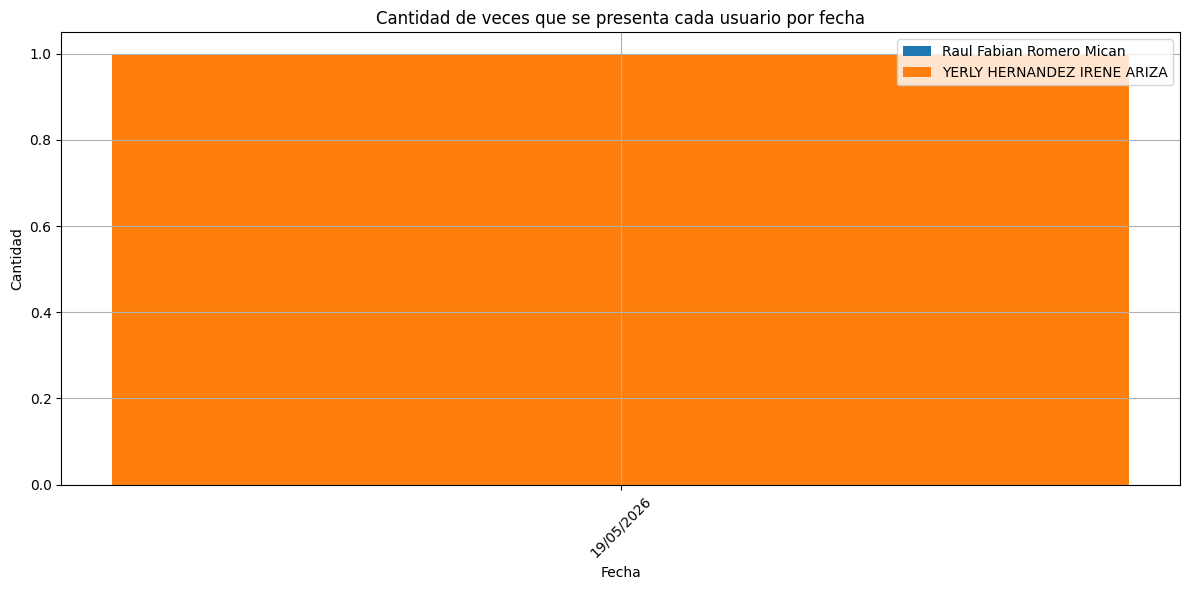

In [276]:
# Agrupar los datos por NombreUsuario y Fecha y contar las ocurrencias
conteo_por_fecha = resultado.groupby(['Nombre de Usuario', 'Fecha']).size().reset_index(name='Conteo')

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
for nombre_usuario in conteo_por_fecha['Nombre de Usuario'].unique():
    datos_usuario = conteo_por_fecha[conteo_por_fecha['Nombre de Usuario'] == nombre_usuario]
    plt.bar(datos_usuario['Fecha'], datos_usuario['Conteo'], label=nombre_usuario)

# Personalizar la gráfica
plt.xlabel('Fecha')
plt.ylabel('Cantidad')
plt.title('Cantidad de veces que se presenta cada usuario por fecha')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

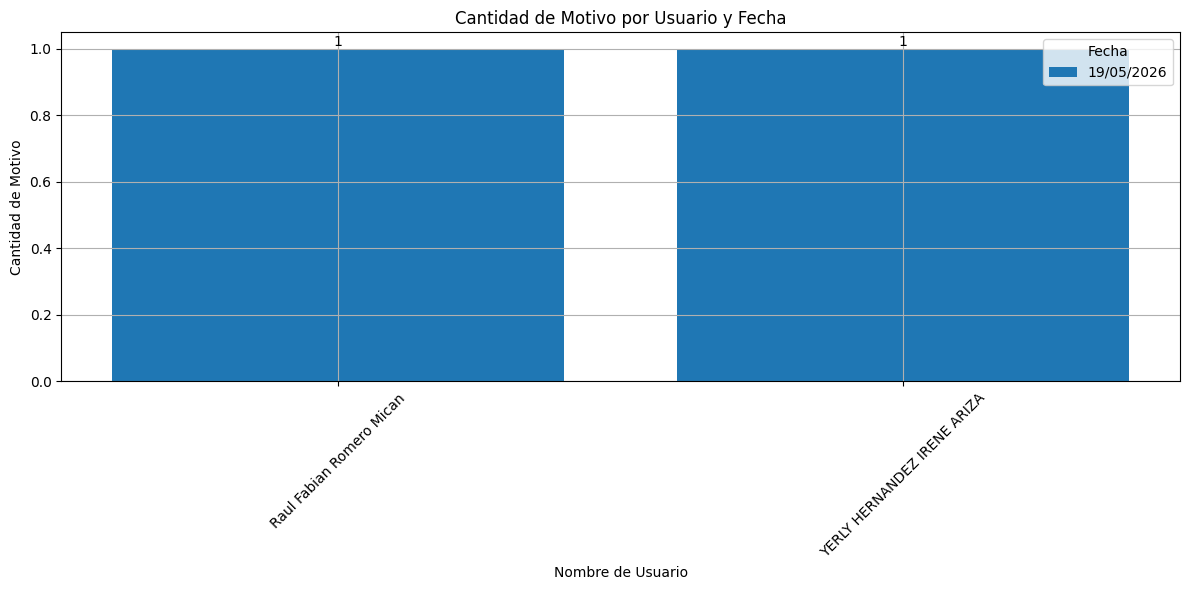

In [277]:
# Agrupar los datos por NombreUsuario y Fecha y contar las descripciones del motivo
conteo_por_usuario_fecha = resultado.groupby(['Nombre de Usuario', 'Fecha'])['Motivo'].count().reset_index(name='Cantidad')

# Crear la gráfica de barras
plt.figure(figsize=(12, 6))
for fecha in conteo_por_usuario_fecha['Fecha'].unique():
    datos_fecha = conteo_por_usuario_fecha[conteo_por_usuario_fecha['Fecha'] == fecha]
    plt.bar(datos_fecha['Nombre de Usuario'], datos_fecha['Cantidad'], label=fecha)

# Agregar etiquetas a las barras
for index, row in conteo_por_usuario_fecha.iterrows():
    plt.text(row['Nombre de Usuario'], row['Cantidad'], str(row['Cantidad']), ha='center', va='bottom')

# Personalizar la gráfica
plt.xlabel('Nombre de Usuario')
plt.ylabel('Cantidad de Motivo')
plt.title('Cantidad de Motivo por Usuario y Fecha')
plt.xticks(rotation=45)
plt.legend(title='Fecha')
plt.grid(True)

# Mostrar la gráfica
plt.tight_layout()
plt.show()

2. Accion igual a 5 - Eliminar coche y Motivo 5

In [278]:
# Filtrar las filas donde 'Accion' sea igual a 5
acciones_rev2 = acciones_rev[acciones_rev['Id Acción'].isin([5])]

acciones_rev2.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
0,19/05/2026,0:12:49,10325,576,3.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
1,19/05/2026,0:13:16,10325,576,7.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
2,19/05/2026,0:13:33,10325,576,12.0,NaN,0.0,5,Eliminar Vehiculo,LJAIMES_112,Luis Eduardo Jaimes,"<= Elimination Vehicle =>\nIdLinea=10325,\nSer...",14,No se presenta conductor a realizar servicio,NaN
151,19/05/2026,2:19:18,10338,BD906,3.0,NaN,0.0,5,Eliminar Vehiculo,AGARCIA_101,ANDERSON GARCIA ERNESTO GALINDO,"<= Elimination Vehicle =>\nIdLinea=10338,\nSer...",1,Concesionario no envía vehículo,NaN
152,19/05/2026,2:19:32,10338,BD906,5.0,NaN,0.0,5,Eliminar Vehiculo,AGARCIA_101,ANDERSON GARCIA ERNESTO GALINDO,"<= Elimination Vehicle =>\nIdLinea=10338,\nSer...",1,Concesionario no envía vehículo,NaN


In [279]:
# Lista de valores de Accion a incluir en el filtro - Motivo 5
valores_interes = [5]

# Filtrar el DataFrame por los valores de Accion de interés
acciones_rev2 = acciones_rev2[acciones_rev2['Id Motivo'].isin(valores_interes)]

acciones_rev2.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN


In [280]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(linea):
    
    filtro = (
        (rutas['linea'] == linea) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev2['ruta_sae'] = acciones_rev2.apply(
    lambda row: calcular_lin(
        row['Id Línea']
    ),
    axis=1
)
acciones_rev2.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856


In [281]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev2['ruta_sae'] = acciones_rev2['ruta_sae'].fillna(1)

acciones_rev2['ruta_sae'] = acciones_rev2['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev2 = acciones_rev2[acciones_rev2['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev2.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856


In [282]:
#concatenar los dataframe
acciones = acciones_rev2.copy()

acciones.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856


In [283]:
# Ordenar el DataFrame por las columnas Fecha, Instante, Linea y Coche
acciones = acciones.sort_values(by=['Fecha', 'Instante', 'Id Línea', 'Tabla'], ascending=True)

acciones.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
700,19/05/2026,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533
736,19/05/2026,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856


In [284]:
# # Filtrar filas donde los valores de la columna 'NumBus' comiencen con 'Z50'
# acciones = acciones[acciones['Código Bus'].astype(str).str.startswith('Z50', 'Z52')]

# # Reiniciar el índice después del filtrado
# acciones.reset_index(drop=True, inplace=True)

# acciones.head()

In [285]:
# Convertir la columna 'Fecha' a formato datetime
acciones['Fecha'] = pd.to_datetime(acciones['Fecha'], errors='coerce')

acciones.head()

C:\Users\Jonny Villareal\AppData\Local\Temp\ipykernel_15524\692094097.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  acciones['Fecha'] = pd.to_datetime(acciones['Fecha'], errors='coerce')


,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
700,2026-05-19,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533
736,2026-05-19,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856


In [286]:
import re

# Definir una función para contar los caracteres en la cadena
def contar_caracteres(cadena):

    if pd.isna(cadena):
        return 0

    return len(str(cadena))


# Aplicar solo cuando Id Acción = 5
acciones['Conteo_Caracteres'] = acciones.loc[
    acciones['Id Acción'] == 5,
    'Parámetros'
].apply(contar_caracteres)


# Función para extraer ServicioBus
def extraer_servicio_accion5(cadena, accion):

    if accion != 5:
        return None

    if pd.isna(cadena):
        return None

    # Nuevo patrón
    patron_servicio = r'ServicioBus=([^\n\r]+)'

    # Buscar coincidencia
    servicio_match = re.search(
        patron_servicio,
        str(cadena)
    )

    # Extraer servicio
    servicio = (
        servicio_match.group(1).strip()
        if servicio_match
        else None
    )

    return servicio


# Aplicar función
acciones['Servicio_eliminado'] = acciones.apply(
    lambda row: extraer_servicio_accion5(
        row['Parámetros'],
        row['Id Acción']
    ),
    axis=1
)

acciones.head(5)

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Conteo_Caracteres,Servicio_eliminado
700,2026-05-19,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533,613,"CE0630003,"
736,2026-05-19,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856,587,"CE1BA0009,"


In [287]:
# #Verificar el motivo de eliminación del servicio
# def determinar_valor(cadena):
#     conteo = len(cadena)
#     if conteo <= 125:
#         return "EliminarCoche"
#     elif 125 < conteo <= 320:
#         return "Desde Ruta / PosicionParada/Retirada Cochera"
#     elif 320 < conteo <= 355:
#         return "Desde Ruta / Hasta Ruta"
#     elif 355 < conteo <= 365:
#         return "Desde Ruta / PosicionParada/Hasta Ruta"
#     elif 365 < conteo <= 430:
#         return "Desde Ruta / Incorporacion Cochera/Hasta Ruta"
#     elif 430 < conteo <= 455:
#         return "Desde Ruta / PosicionParada/Retirada Cochera/Hasta Ruta"
#     elif 455 < conteo <= 505:
#         return "Desde Ruta / Retirada Cochera/ Incorporacion Cochera/Hasta Ruta"
#     else:
#         return "Desde Ruta / Posicion Parada / Retirada Cochera / Incorporacion Cochera/Hasta Ruta"

# # Aplicar la función a la columna "Parametros" solo cuando la columna "Accion" es igual a 5
# acciones['Forma_eliminada'] = acciones.loc[acciones['Accion'] == 5, 'Parametros'].apply(determinar_valor)

# acciones.head(5)

In [288]:
# # Obtener el conteo de cada valor único en la columna 'Servicio_eliminado'
# conteo_valores = acciones['Servicio_eliminado'].value_counts()

# # Mapear los valores de la columna 'Servicio_eliminado' al conteo correspondiente
# acciones['Conteo_Servicio_eliminado'] = acciones['Servicio_eliminado'].map(conteo_valores)

# # Mostrar el DataFrame con la nueva columna 'Conteo_Servicio_eliminado'
# acciones.head(5)

In [289]:
iph.head()

,Jornada,TipoDia,Concesionario de Operación,Instante,Servicio Bus,Evento,Id Línea,Tabla,Sublinea,Id Ruta,Id Nodo,Tipo Nodo,Viaje,Servicio Conductor entrante,Servicio Conductor Saliente,Tipo Vehiculo,Ruta
2,GC260519T2,CN0010079501,GMOVIL ENGATIVA,4:00:00,CN31B0001,11,10339,1,2496,12756.0,52372,Parada,2,CE101274,CE101274,BUS (80),12756
14,GC260519T2,CN0010079501,GMOVIL ENGATIVA,5:54:45,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,3,CE101515,CE101274,BUS (80),12756
26,GC260519T2,CN0010079501,GMOVIL ENGATIVA,9:04:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,4,CE101549,CE101515,BUS (80),12756
38,GC260519T2,CN0010079501,GMOVIL ENGATIVA,12:10:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,5,CE101477,CE101549,BUS (80),12756
50,GC260519T2,CN0010079501,GMOVIL ENGATIVA,15:10:00,CN31B0001,3,10339,1,2496,12756.0,52372,Parada,6,CE101655,CE101477,BUS (80),12756


In [290]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (iph['Servicio Bus'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not iph.loc[filtro].empty:
        # Obtener el primer valor
        tipo = iph.loc[filtro, 'Viaje'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones['Viaje'] = acciones.apply(
    lambda row: calcular_lin(
        row['Servicio_eliminado']
    ),
    axis=1
)

acciones.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Conteo_Caracteres,Servicio_eliminado,Viaje
700,2026-05-19,9:33:26,10266,DD204,3.0,NaN,0.0,5,Eliminar Vehiculo,RROMERO_105,Raul Fabian Romero Mican,"<= Elimination Vehicle =>\nIdLinea=10266,\nSer...",5,Congestion vehicular,NaN,10533,613,"CE0630003,",None
736,2026-05-19,9:54:31,10551,KL307,9.0,NaN,0.0,5,Eliminar Vehiculo,YHERNANDEZ_105,YERLY HERNANDEZ IRENE ARIZA,"<= Elimination Vehicle =>\nIdLinea=10551,\nSer...",5,Congestion vehicular,NaN,12856,587,"CE1BA0009,",None


Acciones de regulacion - Accion 36 (Cambiar de coche)

In [291]:
acciones_rev3 = acciones_rev3.loc[acciones_rev3['Id Acción'] == 36]

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN


In [292]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (rutas['linea'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev3['ruta_sae'] = acciones_rev3.apply(
    lambda row: calcular_lin(
        row['Id Línea']
    ),
    axis=1
)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632.0
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777.0
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328.0
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785.0
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058.0


In [293]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].fillna(1)

acciones_rev3['ruta_sae'] = acciones_rev3['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev3 = acciones_rev3[acciones_rev3['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058


In [294]:
# Extraer servicio de referencia
acciones_rev3['Servicio de Referencia'] = (
    acciones_rev3['Parámetros']
    .str.extract(r'ServBusRef=([^\n\r]+)')[0]
)

# Extraer nuevo servicio
acciones_rev3['Servicio Nuevo'] = (
    acciones_rev3['Parámetros']
    .str.extract(r'ServBusNuevo=([^\n\r]+)')[0]
)

# Limpiar espacios
acciones_rev3['Servicio de Referencia'] = (
    acciones_rev3['Servicio de Referencia']
    .astype(str)
    .str.strip()
)

acciones_rev3['Servicio Nuevo'] = (
    acciones_rev3['Servicio Nuevo']
    .astype(str)
    .str.strip()
)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia,Servicio Nuevo
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632,"CE12B0003,","CE12BG003,"
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777,"CE1630010,","CE163G010,"
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328,"CE12D0033,","CE12DG033,"
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785,"CE1690006,","CE169G006,"
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058,"CE1B60007,","CE1B6G007,"


In [295]:
# Extraer IdViajeDesdeRef
acciones_rev3['Viaje Ini'] = (
    acciones_rev3['Parámetros']
    .str.extract(r'IdViajeDesdeRef=([^\n\r]+)')[0]
)

# Limpiar
acciones_rev3['Viaje Ini'] = (
    acciones_rev3['Viaje Ini']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia,Servicio Nuevo,Viaje Ini
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632,"CE12B0003,","CE12BG003,","3,"
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777,"CE1630010,","CE163G010,","3,"
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328,"CE12D0033,","CE12DG033,","3,"
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785,"CE1690006,","CE169G006,","3,"
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058,"CE1B60007,","CE1B6G007,","3,"


In [296]:
# Extraer IdViajeHastaRef
acciones_rev3['Viaje_fin'] = (
    acciones_rev3['Parámetros']
    .str.extract(r'IdViajeHastaRef=([^\n\r]+)')[0]
)

# Limpiar valores
acciones_rev3['Viaje_fin'] = (
    acciones_rev3['Viaje_fin']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia,Servicio Nuevo,Viaje Ini,Viaje_fin
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,Raul Fabian Romero Mican,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632,"CE12B0003,","CE12BG003,","3,","3,"
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,DORIS PATARROYO EDITH GORDO,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777,"CE1630010,","CE163G010,","3,","4,"
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,JINNETH GUZMAN ALEXANDRA HERNANDEZ,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328,"CE12D0033,","CE12DG033,","3,","3,"
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,ADRIANA TELLEZ PATRICIA VARELA,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785,"CE1690006,","CE169G006,","3,","4,"
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,JIMMY ALEXANDER CARABALLO DIAZ,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058,"CE1B60007,","CE1B6G007,","3,","3,"


In [297]:
# Extraer ServBusNuevo
acciones_rev3['Nombre Servicio'] = (
    acciones_rev3['Parámetros']
    .str.extract(r'ServBusNuevo=([^\n\r]+)')[0]
)

# Limpiar valores
acciones_rev3['Nombre Servicio'] = (
    acciones_rev3['Nombre Servicio']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,...,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia,Servicio Nuevo,Viaje Ini,Viaje_fin,Nombre Servicio
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,...,"<= Change Vehicle =>\nIdLinea=10331,\nServBusR...",26,Retoma de viaje,NaN,10632,"CE12B0003,","CE12BG003,","3,","3,","CE12BG003,"
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,...,"<= Change Vehicle =>\nIdLinea=10310,\nServBusR...",26,Retoma de viaje,NaN,12777,"CE1630010,","CE163G010,","3,","4,","CE163G010,"
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,...,"<= Change Vehicle =>\nIdLinea=10264,\nServBusR...",26,Retoma de viaje,NaN,12328,"CE12D0033,","CE12DG033,","3,","3,","CE12DG033,"
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,...,"<= Change Vehicle =>\nIdLinea=10194,\nServBusR...",26,Retoma de viaje,NaN,12785,"CE1690006,","CE169G006,","3,","4,","CE169G006,"
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,...,"<= Change Vehicle =>\nIdLinea=10261,\nServBusR...",26,Retoma de viaje,NaN,13058,"CE1B60007,","CE1B6G007,","3,","3,","CE1B6G007,"


In [302]:
# Susituyente de sustituyente

acciones_rev3['Sustituyente de Sustituyente'] = acciones_rev3.apply(lambda row: 'Si' if row['Nombre Servicio'] == row['Servicio de Referencia'] else 'No', axis=1)

# Creando servicio original

acciones_rev3['Servicio Planificado'] = acciones_rev3['Nombre Servicio'].str[:5] + '0' + acciones_rev3['Nombre Servicio'].str[-3:]

# Crear una nueva columna 'Conteo' 

acciones_rev3['Numero de sustituyente'] = acciones_rev3.apply(lambda row: 
    len(acciones_rev3[(acciones_rev3['Servicio de Referencia'] < row['Servicio de Referencia']) & 
                    (acciones_rev3['Servicio Planificado'] == row['Servicio Planificado'])]) + 1, axis=1)

acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,...,Reversada por,ruta_sae,Servicio de Referencia,Servicio Nuevo,Viaje Ini,Viaje_fin,Nombre Servicio,Sustituyente de Sustituyente,Servicio Planificado,Numero de sustituyente
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,...,NaN,10632,"CE12B0003,","CE12BG003,","3,","3,","CE12BG003,",No,"CE12B003,",1
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,...,NaN,12777,"CE1630010,","CE163G010,","3,","4,","CE163G010,",No,"CE163010,",1
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,...,NaN,12328,"CE12D0033,","CE12DG033,","3,","3,","CE12DG033,",No,"CE12D033,",1
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,...,NaN,12785,"CE1690006,","CE169G006,","3,","4,","CE169G006,",No,"CE169006,",1
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,...,NaN,13058,"CE1B60007,","CE1B6G007,","3,","3,","CE1B6G007,",No,"CE1B6007,",1


In [306]:
# Limpiar columnas antes de convertir
acciones_rev3['Viaje_fin'] = (
    acciones_rev3['Viaje_fin']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

acciones_rev3['Viaje Ini'] = (
    acciones_rev3['Viaje Ini']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Convertir a numérico
acciones_rev3['Viaje_fin'] = pd.to_numeric(
    acciones_rev3['Viaje_fin'],
    errors='coerce'
).fillna(0).astype(int)

acciones_rev3['Viaje Ini'] = pd.to_numeric(
    acciones_rev3['Viaje Ini'],
    errors='coerce'
).fillna(0).astype(int)

# Limpiar Numero de sustituyente
acciones_rev3['Numero de sustituyente'] = pd.to_numeric(
    acciones_rev3['Numero de sustituyente'],
    errors='coerce'
).fillna(0).astype(int)



def calcular_resultado(row):

    try:

      
        # Sustituyente NO
  
        if (
            row['Sustituyente de Sustituyente'] == "No"
            and row['Numero de sustituyente'] >= 1
            and row['Viaje_fin'] > row['Viaje Ini']
        ):

            return (
                row['Viaje_fin']
                - row['Viaje Ini']
            )


       
        # Sustituyente SI
     
        if row['Sustituyente de Sustituyente'] == "Si":

            viaje_ini_lookup = acciones_rev3[

                (
                    acciones_rev3['Servicio de Referencia']
                    == row['Servicio de Referencia']
                )

                &

                (
                    acciones_rev3['Nombre Servicio']
                    == row['Nombre Servicio']
                )

            ]['Viaje Ini'].values


            # Si no encuentra referencia
            if len(viaje_ini_lookup) == 0:

                if row['Viaje_fin'] == row['Viaje Ini']:
                    return 1

                return (
                    row['Viaje_fin']
                    - row['Viaje Ini']
                )


            # Primer sustituyente
            if row['Numero de sustituyente'] == 1:

                return (
                    row['Viaje_fin']
                    - row['Viaje Ini']
                    + 1
                )


            # Buscar sustituyente anterior
            viaje_ini_anterior = acciones_rev3[

                (
                    acciones_rev3['Servicio Planificado']
                    == row['Servicio Planificado']
                )

                &

                (
                    acciones_rev3['Numero de sustituyente']
                    == row['Numero de sustituyente'] - 1
                )

            ]['Viaje Ini'].values


            if len(viaje_ini_anterior) > 0:

                return (
                    viaje_ini_lookup[0]
                    - row['Viaje Ini']
                    - 1
                )


     
        # Cuando inicio y fin son iguales
      
        if (
            row['Sustituyente de Sustituyente'] == "No"
            and row['Viaje_fin'] == row['Viaje Ini']
        ):

            return 1


        return 0

    except:

        return 0


if not acciones_rev3.empty:

    acciones_rev3['N Viajes'] = (
        acciones_rev3.apply(
            calcular_resultado,
            axis=1
        )
    )

else:

    acciones_rev3['N Viajes'] = 0


acciones_rev3.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,...,ruta_sae,Servicio de Referencia,Servicio Nuevo,Viaje Ini,Viaje_fin,Nombre Servicio,Sustituyente de Sustituyente,Servicio Planificado,Numero de sustituyente,N Viajes
324,19/05/2026,6:31:11,10331,12,3.0,Z50-4392,504392.0,36,Retomar Viajes,RROMERO_105,...,10632,"CE12B0003,","CE12BG003,",3,3,"CE12BG003,",No,"CE12B003,",1,1
332,19/05/2026,6:34:59,10310,C101,4.0,Z50-2073,502073.0,36,Retomar Viajes,DPATARROYO_105,...,12777,"CE1630010,","CE163G010,",3,4,"CE163G010,",No,"CE163010,",1,1
345,19/05/2026,6:44:30,10264,614,33.0,Z50-4303,504303.0,36,Retomar Viajes,JGUZMAN_105,...,12328,"CE12D0033,","CE12DG033,",3,3,"CE12DG033,",No,"CE12D033,",1,1
365,19/05/2026,6:55:34,10194,539,3.0,Z50-7042,507042.0,36,Retomar Viajes,ATELLEZ_105,...,12785,"CE1690006,","CE169G006,",3,4,"CE169G006,",No,"CE169006,",1,1
368,19/05/2026,7:00:42,10261,466,7.0,Z50-7000,507000.0,36,Retomar Viajes,JDURAN_105,...,13058,"CE1B60007,","CE1B6G007,",3,3,"CE1B6G007,",No,"CE1B6007,",1,1


In [308]:
# #N Viajes

# # Convierte las columnas 'Viaje Fin' y 'Viaje Ini' a tipo numérico (int)
# acciones_rev3['Viaje_fin'] = acciones_rev3['Viaje_fin'].astype(int)
# acciones_rev3['Viaje Ini'] = acciones_rev3['Viaje Ini'].astype(int)


# def calcular_resultado(row):
#     if row['Sustituyente de Sustituyente'] == "No" and \
#         row['Numero de sustituyente'] >= 1 and \
#         row['Viaje_fin'] > row['Viaje Ini']:
#         return row['Viaje_fin'] - row['Viaje Ini']
    
#     if row['Sustituyente de Sustituyente'] == "Si":
#         viaje_ini_lookup = acciones_rev3[(acciones_rev3['Servicio de Referencia'] == row['Servicio de Referencia']) & (acciones_rev3['Nombre Servicio'] == row['Nombre Servicio'])]['Viaje Ini'].values
#         if len(viaje_ini_lookup) == 0:
#             return 1 if row['Viaje_fin'] == row['Viaje Ini'] else row['Viaje_fin'] - row['Viaje Ini']
        
#         if row['Numero de sustituyente'] == 1:
#             return row['Viaje_fin'] - row['Viaje Ini'] + 1
        
#         viaje_ini_anterior = acciones_rev3[(acciones_rev3['Servicio Planificado'] == row['Servicio Planificado']) & (acciones_rev3['Numero de sustiituyente'] == row['Numero de sustituyente'] - 1)]['Viaje Ini'].values
#         if len(viaje_ini_anterior) > 0:
#             return viaje_ini_lookup[0] - row['Viaje Ini'] - 1
        
#     if row['Sustituyente de Sustituyente'] == "No" and row['Viaje_fin'] == row['Viaje Ini']:
#         return 1
    
#     return None

# # acciones_rev3['N Viajes'] = acciones_rev3.apply(calcular_resultado, axis=1)

# acciones_rev3.head()

Acción de regulación introducir coche

In [309]:
acciones_rev4 = acciones_rev.copy()

acciones_rev4 = acciones_rev4.loc[acciones_rev4['Id Acción'] == 4]

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por


In [310]:
# Llevar ruta_sae a eliminaciones Motivo 31

def calcular_lin(svb):
    
    filtro = (
        (rutas['linea'] == svb) 
    )
    
    # Verificar si hay algún resultado después de aplicar el filtro
    if not rutas.loc[filtro].empty:
        # Obtener el primer valor
        tipo = rutas.loc[filtro, 'ruta_sae'].iloc[0]
        return tipo if not pd.isna(tipo) else None 
    
    return None  # Devolver None si no hay resultados

# Aplica la función a las columnas correspondientes
acciones_rev4['ruta_sae'] = acciones_rev4.apply(
    lambda row: calcular_lin(
        row['Id Línea']
    ),
    axis=1
)

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae


In [311]:
# Rellenar los valores vacíos (NaN) en la columna 'ruta_sae' con 1
acciones_rev4['ruta_sae'] = acciones_rev4['ruta_sae'].fillna(1)

acciones_rev4['ruta_sae'] = acciones_rev4['ruta_sae'].astype(int)

# Eliminar las filas donde 'ruta_sae' sea igual a 1
acciones_rev4 = acciones_rev4[acciones_rev4['ruta_sae'] != 1]

# Verificar los cambios
acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae


In [312]:
# Extraer vehServId como servicio de referencia
acciones_rev4['Servicio de Referencia'] = (
    acciones_rev4['Parámetros']
    .str.extract(r'vehServId=([^\n\r\]]+)')[0]
)

# Limpiar valores
acciones_rev4['Servicio de Referencia'] = (
    acciones_rev4['Servicio de Referencia']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia


In [313]:
# Extraer fromServTripSeq como Viaje Ini
acciones_rev4['Viaje Ini'] = (
    acciones_rev4['Parámetros']
    .str.extract(r'fromServTripSeq=([^\n\r]+)')[0]
)

# Limpiar valores
acciones_rev4['Viaje Ini'] = (
    acciones_rev4['Viaje Ini']
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,ruta_sae,Servicio de Referencia,Viaje Ini


In [314]:
# Filtrar acción 4
acciones_rev4 = acciones_rev.copy()

acciones_rev4 = acciones_rev4.loc[
    acciones_rev4['Id Acción'] == 4
].copy()


# Función para extraer viajes
def extract_viajes(parametros):

    texto = str(parametros)

    viaje_ini = re.search(
        r'fromServTripSeq=(\d+)',
        texto
    )

    viaje_fin = re.search(
        r'toServTripSeq=(\d+)',
        texto
    )

    return pd.Series([
        viaje_ini.group(1) if viaje_ini else None,
        viaje_fin.group(1) if viaje_fin else None
    ])


# Validar si existen registros
if not acciones_rev4.empty:

    acciones_rev4[
        ['Viaje Ini', 'Viaje_fin']
    ] = acciones_rev4['Parámetros'].apply(
        extract_viajes
    )

else:

    acciones_rev4['Viaje Ini'] = None
    acciones_rev4['Viaje_fin'] = None


# Convertir a entero
acciones_rev4['Viaje Ini'] = pd.to_numeric(
    acciones_rev4['Viaje Ini'],
    errors='coerce'
).fillna(0).astype(int)

acciones_rev4['Viaje_fin'] = pd.to_numeric(
    acciones_rev4['Viaje_fin'],
    errors='coerce'
).fillna(0).astype(int)


acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Viaje Ini,Viaje_fin


In [315]:
# # Función para extraer el viaje inicial y final
# def extract_viajes(parametros):

#     texto = str(parametros)

#     # Buscar fromServTripSeq y toServTripSeq
#     viaje_ini = re.search(r'fromServTripSeq=(\d+)', texto)
#     viaje_fin = re.search(r'toServTripSeq=(\d+)', texto)

#     return pd.Series([
#         viaje_ini.group(1) if viaje_ini else None,
#         viaje_fin.group(1) if viaje_fin else None
#     ])


# # Crear columnas
# acciones_rev4[['Viaje Ini', 'Viaje_fin']] = (
#     acciones_rev4['Parámetros']
#     .apply(extract_viajes)
# )

# # Convertir a entero
# acciones_rev4['Viaje Ini'] = pd.to_numeric(
#     acciones_rev4['Viaje Ini'],
#     errors='coerce'
# ).fillna(0).astype(int)

# acciones_rev4['Viaje_fin'] = pd.to_numeric(
#     acciones_rev4['Viaje_fin'],
#     errors='coerce'
# ).fillna(0).astype(int)

# acciones_rev4.head()

In [316]:
# Buscar vehServId
acciones_rev4['Nombre Servicio'] = (
    acciones_rev4['Parámetros']
    .str.extract(r'vehServId=([A-Z0-9]+)')[0]
)

# Convertir a texto
acciones_rev4['Nombre Servicio'] = (
    acciones_rev4['Nombre Servicio']
    .astype(str)
    .str.strip()
)

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Viaje Ini,Viaje_fin,Nombre Servicio


In [317]:
#Buscar incorporación

# Función personalizada para extraer la subcadena
def extraer_incorporacion_cochera(parametros):
    start = parametros.find("Incorporacion Cochera=")
    if start != -1:
        substring = parametros[start + len("Incorporacion Cochera="):start + len("Incorporacion Cochera=") + 9]
        return substring
    else:
        return None

# Aplicar la función personalizada a la columna 'Parámetros'
acciones_rev4['Con Incorporacion'] = acciones_rev4['Parámetros'].apply(lambda x: 1 if extraer_incorporacion_cochera(x) is not None else 0)

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion


In [318]:
#N Viajes

# Convierte las columnas 'Viaje Fin' y 'Viaje Ini' a tipo numérico (int)
acciones_rev4['Viaje_fin'] = acciones_rev4['Viaje_fin'].astype(int)
acciones_rev4['Viaje Ini'] = acciones_rev4['Viaje Ini'].astype(int)

# Primera condición: LOOKUPVALUE(Retomas[Viaje Ini]; Retomas[Servicio de Referencia]; Retomas[Nombre Servicio]) = 2
# y Retomas[Con Incorporación] = 1
condicion_1 = (acciones_rev4['Viaje Ini'] == 2) & (acciones_rev4['Con Incorporacion'] == 1)

# Si se cumple la primera condición, el resultado es 0; de lo contrario, calculamos Retomas[Viaje Fin] - Retomas[Viaje Ini] + 1
acciones_rev4['N Viajes'] = 0
acciones_rev4.loc[~condicion_1, 'N Viajes'] = acciones_rev4['Viaje_fin'] - acciones_rev4['Viaje Ini'] + 1

acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,Nombre de Usuario,Parámetros,Id Motivo,Motivo,Reversada por,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion,N Viajes


In [319]:
# Verificar si existen registros
if not acciones_rev4.empty:

    # Función para Servicio Planificado
    def buscar_valor(row):

        servicio_ref = str(row['Servicio de Referencia'])

        if servicio_ref[:2] == "RT":

            filtro = acciones_rev4[
                acciones_rev4['Nombre Servicio'] == servicio_ref
            ]

            if not filtro.empty:
                return filtro['Servicio de Referencia'].iloc[0]

            return servicio_ref

        else:
            return servicio_ref


    # Aplicar función
    acciones_rev4['Servicio Planificado'] = (
        acciones_rev4.apply(buscar_valor, axis=1)
    )

else:

    # Crear columna vacía si no hay datos
    acciones_rev4['Servicio Planificado'] = None


acciones_rev4.head()

,Fecha,Instante,Id Línea,Línea,Tabla,Código Bus,Número FMS Bus,Id Acción,Descripción de Acción,Id Usuario,...,Parámetros,Id Motivo,Motivo,Reversada por,Viaje Ini,Viaje_fin,Nombre Servicio,Con Incorporacion,N Viajes,Servicio Planificado


In [ ]:
# #exportar acciones de regulación
# acciones.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/acciones_eliminación.csv', sep= ';', index=False)

In [ ]:
# #exportar notas
# notas.to_csv('C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/notas_acciones_eliminación.csv', sep= ';', index=False)

In [320]:
#exportar desglosado
desglosado.to_csv(f'C:/Users/Jonny Villareal/OneDrive - Gmovil SAS/Escritorio/Jonny/Control 2024/Notas/{dia}_desglosado_eliminación.csv', sep= ';', index=False)